# Olist CLV-ML — EDA: Enriched Features

## Context
Following initial EDA, three new features were added to better capture 
first-purchase behavior signals and reduce the direct relationship between 
`monetary` and `total_ltv`:

- `payment_type` — payment method of the first purchase
- `payment_installments` — number of installments chosen
- `product_category_name_english` — category of the highest-value product 
  in the first purchase

This notebook analyzes the distribution and predictive power of these new features.

## Setup

In [3]:
df = pd.read_csv('../data/clean/features.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (93358, 10)


,customer_unique_id,days_since_first_purchase,frequency,monetary,max_review_score,avg_review_score,payment_type,payment_installments,product_category_name_english,total_ltv
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,5.0,5.0,credit_card,8.0,bed_bath_table,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,4.0,4.0,credit_card,1.0,health_beauty,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00,3.0,3.0,credit_card,8.0,stationery,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99,4.0,4.0,credit_card,4.0,telephony,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00,5.0,5.0,credit_card,6.0,telephony,180.00


## 1. Payment Type Distribution

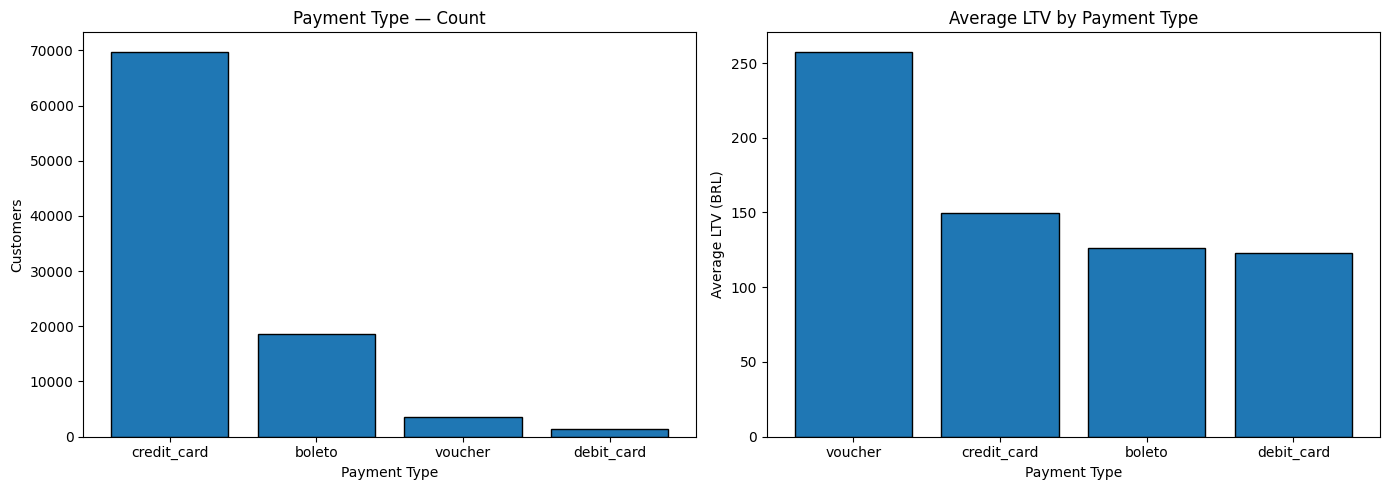

              count    mean  median
payment_type                       
boleto        18625  126.18   77.70
credit_card   69791  149.70   92.10
debit_card     1441  122.72   72.00
voucher        3500  257.67  127.99


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
payment_counts = df['payment_type'].value_counts()
axes[0].bar(payment_counts.index, payment_counts.values, edgecolor='black')
axes[0].set_title('Payment Type — Count')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Customers')

# LTV promedio por tipo de pago
payment_ltv = df.groupby('payment_type')['total_ltv'].mean().sort_values(ascending=False)
axes[1].bar(payment_ltv.index, payment_ltv.values, edgecolor='black')
axes[1].set_title('Average LTV by Payment Type')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Average LTV (BRL)')

plt.tight_layout()
plt.show()

print(df.groupby('payment_type')['total_ltv'].agg(['count', 'mean', 'median']).round(2))

### Findings

- **credit_card** dominates with 75% of customers, followed by **boleto** (20%)
- **voucher** has the highest average LTV (BRL 258) despite being used by very few customers, 
  likely corporate or promotional purchases with higher ticket values
- **credit_card** customers have significantly higher LTV than boleto and debit_card users, 
  suggesting payment method is a meaningful signal of purchasing power

This variable is expected to be a useful predictor despite the class imbalance 
between payment types.

## 2. Payment Installments Distribution

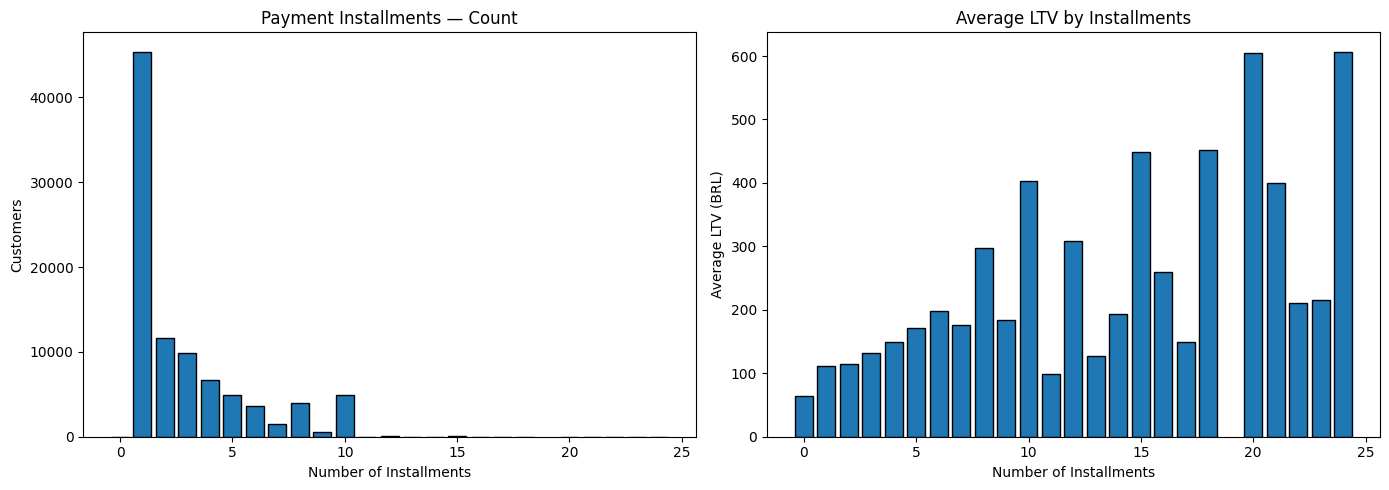

                      count    mean  median
payment_installments                       
0.0                       2   64.64   64.64
1.0                   45405  111.37   65.00
2.0                   11696  114.63   95.00
3.0                    9813  131.61   99.00
4.0                    6641  149.75   99.99
5.0                    4886  170.90  110.00
6.0                    3647  197.40  122.99
7.0                    1497  175.55  119.85
8.0                    3952  296.84  198.45
9.0                     593  184.06   99.90
10.0                   4916  403.66  225.64
11.0                     22   98.14   95.65
12.0                    122  308.19  168.00
13.0                     11  127.51  116.99
14.0                     13  193.63  129.00
15.0                     67  447.95  239.90
16.0                      5  259.76  152.00
17.0                      7  149.75  149.99
18.0                     25  451.20  339.44
20.0                     15  605.47  405.89
21.0                      2  399

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución
installment_counts = df['payment_installments'].value_counts().sort_index()
axes[0].bar(installment_counts.index, installment_counts.values, edgecolor='black')
axes[0].set_title('Payment Installments — Count')
axes[0].set_xlabel('Number of Installments')
axes[0].set_ylabel('Customers')

# LTV promedio por cuotas
installment_ltv = df.groupby('payment_installments')['total_ltv'].mean()
axes[1].bar(installment_ltv.index, installment_ltv.values, edgecolor='black')
axes[1].set_title('Average LTV by Installments')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Average LTV (BRL)')

plt.tight_layout()
plt.show()

print(df.groupby('payment_installments')['total_ltv'].agg(['count', 'mean', 'median']).round(2))

### Findings

- Most customers pay in **1 installment** (~46,000), followed by 2 installments (~11,500)
- Clear positive relationship between number of installments and average LTV, 
  customers who pay in more installments tend to spend more in total
- This makes intuitive sense: higher-value purchases are more likely to be financed 
  in multiple installments
- The 0-installment group likely corresponds to boleto or voucher payments

`payment_installments` is expected to be a meaningful predictor of LTV.

## 3. Product Category Distribution

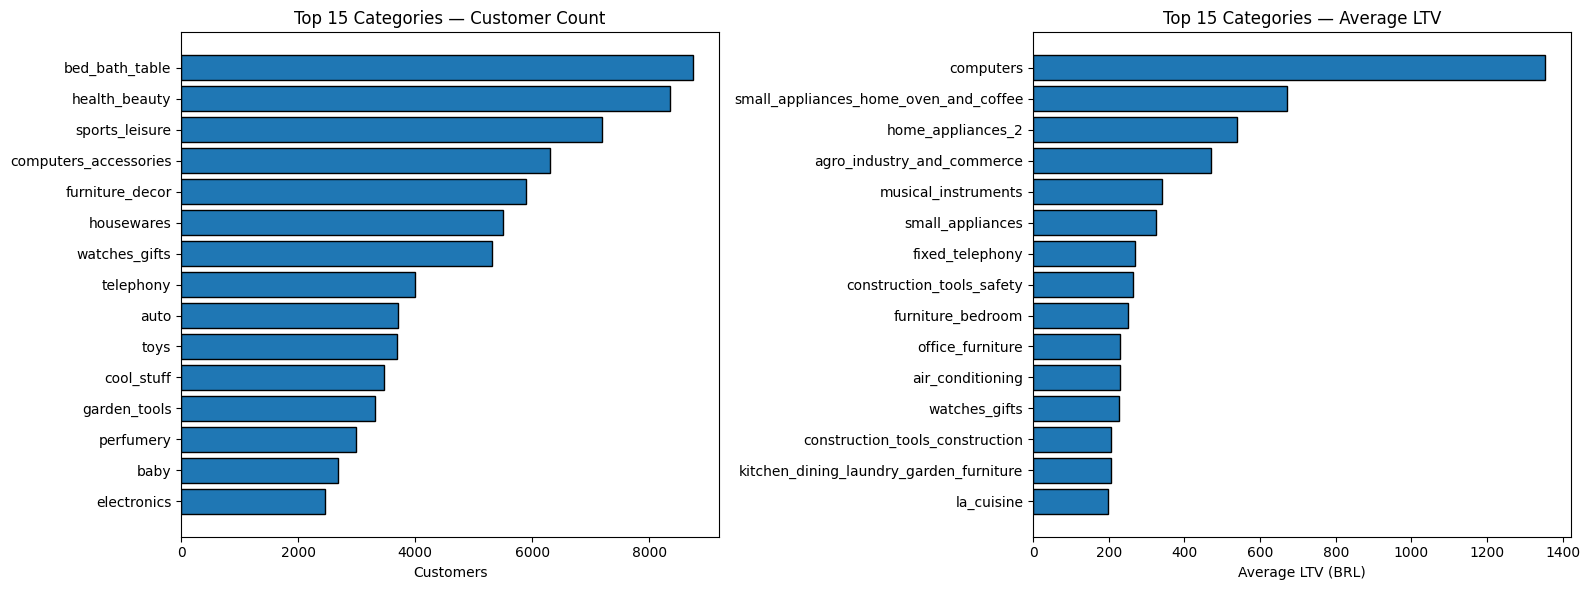

Total unique categories: 71
Missing categories: 1338


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 categorías por cantidad de clientes
top_categories = df['product_category_name_english'].value_counts().head(15)
axes[0].barh(top_categories.index[::-1], top_categories.values[::-1], edgecolor='black')
axes[0].set_title('Top 15 Categories — Customer Count')
axes[0].set_xlabel('Customers')

# Top 15 categorías por LTV promedio
top_ltv_categories = df.groupby('product_category_name_english')['total_ltv'].mean().sort_values(ascending=False).head(15)
axes[1].barh(top_ltv_categories.index[::-1], top_ltv_categories.values[::-1], edgecolor='black')
axes[1].set_title('Top 15 Categories — Average LTV')
axes[1].set_xlabel('Average LTV (BRL)')

plt.tight_layout()
plt.show()

print(f"Total unique categories: {df['product_category_name_english'].nunique()}")
print(f"Missing categories: {df['product_category_name_english'].isnull().sum()}")

### Findings

- **bed_bath_table** and **health_beauty** are the most purchased categories, 
  but they don't appear in the top LTV categories
- **computers** has the highest average LTV (BRL ~1350) by a large margin, 
  a customer whose first purchase is a computer is worth 15x more than the median customer
- The top LTV categories are high-ticket items: computers, appliances, musical instruments
- This confirms that product category is a strong signal of customer value and 
  justifies its inclusion as a feature
- 71 unique categories with no missing values

**Implication for modeling:** Target Encoding will capture this LTV signal 
per category directly, making it more informative than One-Hot Encoding.

## 4. Correlation of New Features with LTV

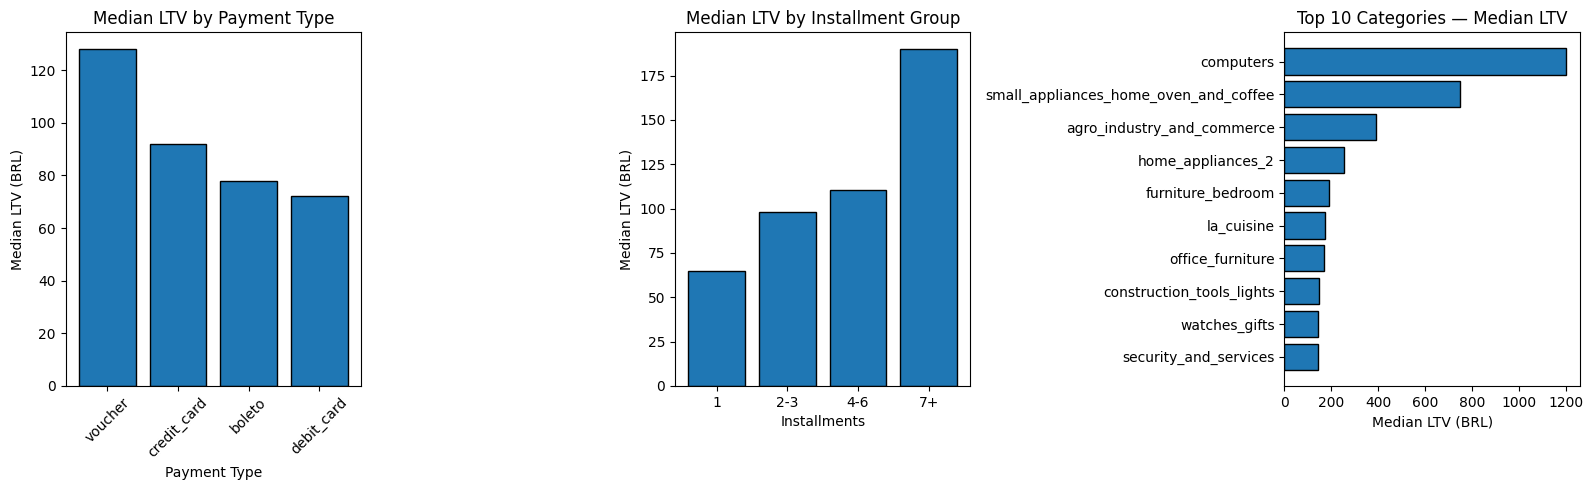

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# LTV por payment_type
payment_ltv = df.groupby('payment_type')['total_ltv'].median().sort_values(ascending=False)
axes[0].bar(payment_ltv.index, payment_ltv.values, edgecolor='black')
axes[0].set_title('Median LTV by Payment Type')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Median LTV (BRL)')
axes[0].tick_params(axis='x', rotation=45)

# LTV por installments (agrupado)
df['installment_group'] = pd.cut(df['payment_installments'], 
                                  bins=[0, 1, 3, 6, 24], 
                                  labels=['1', '2-3', '4-6', '7+'])
installment_ltv = df.groupby('installment_group', observed=True)['total_ltv'].median()
axes[1].bar(installment_ltv.index, installment_ltv.values, edgecolor='black')
axes[1].set_title('Median LTV by Installment Group')
axes[1].set_xlabel('Installments')
axes[1].set_ylabel('Median LTV (BRL)')

# Top 10 categorías por LTV mediano
top_cat_ltv = df.groupby('product_category_name_english')['total_ltv'].median().sort_values(ascending=False).head(10)
axes[2].barh(top_cat_ltv.index[::-1], top_cat_ltv.values[::-1], edgecolor='black')
axes[2].set_title('Top 10 Categories — Median LTV')
axes[2].set_xlabel('Median LTV (BRL)')

plt.tight_layout()
plt.show()

### Findings

- **Payment type:** voucher customers have the highest median LTV (BRL 128), 
  followed by credit_card (BRL 91). Clear signal despite class imbalance.

- **Installments:** strong positive relationship, customers paying in 7+ installments 
  have nearly 3x the median LTV of single-payment customers. 
  More installments = higher ticket purchase = higher LTV.

- **Product category:** computers median LTV (BRL 1200) is 13x the overall median (BRL 89). 
  Category is the strongest new signal introduced in this iteration.

## Summary

All three new features show meaningful relationships with LTV and justify their 
inclusion in the model. Combined with the original RFM features, the enriched 
dataset reduces the direct monetary → LTV relationship by adding behavioral 
and categorical context from the first purchase.

| Feature | Signal strength | Encoding |
|---|---|---|
| payment_type | Moderate | One-Hot Encoding |
| payment_installments | Strong | StandardScaler |
| product_category_name_english | Strong | Target Encoding |